# Quick comparison plotting

## Description
The giwaxs_toolbox has options for quick comparison plots, where given a list of files the plotter can create plots for quick comparisons

The first step is to create a comparison plotter using the commands, where the plotter can take anyname:

```python
    %matplotlib ipympl 
    plotter=comparison_plotter(datafolder='path/to/your/data')
```

Once you have the plotter object, you can then pass it a list of files and it will plot them for comparison. Note that all files must be of the same type. 

first define youfiles

```python
    filelist=['file1.hdf5','file2.hdf5']
```

if there is a single datset within each file, then you can simply enter the filenames and whether you want log scaling. 
    
```python
    combo_plotter.plot_files(filelist,logscale=True)
```

however if you files contain multiple datasets, you need to include a list of the indexes of the dataset you want to plot. For comparing files with multiple datasets to files with a single dataset, the index values shoudl be set to 0 for the file with a single dataset. Note that both index1 values and index2 values must be the same length as the filelist. 


```python
    # here file 1 is a single dataset so its indexes are 0
    # file 2 is (m x n x datashape) - selection is m=8 n=2
    ind1vals=np.array([0,8])  
    ind2vals=np.array([0,2])
    combo_plotter.plot_files(filelist,logscale=True)
```





## Code example

In [1]:
from giwaxs_toolbox.plotting import comparison_plotter, reset_plots
import numpy as np
#set interactive ipympl
%matplotlib ipympl

folder1="/dls/science/groups/das/ExampleData/i07/fast_rsm_example_data/tests_versioned/v2.4.1_i07_2026-04-14"


#load the comparison plotter
combo_plotter=comparison_plotter(datafolder=folder1)




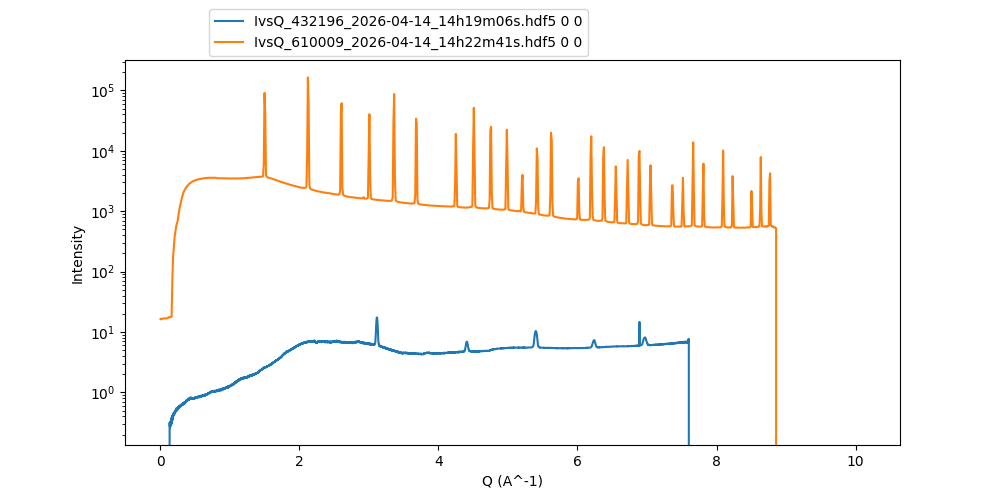

In [3]:

example_ivqfiles=['IvsQ_432196_2026-04-14_14h19m06s.hdf5',
                  'IvsQ_610009_2026-04-14_14h22m41s.hdf5']
combo_plotter.plot_files(example_ivqfiles,logscale=True)

This will give an interactive plot with all the files given to the plotter e.g. 

![image1.png](../images/combo_ivsq.png)

You can also use the same combo_plotter object on different scan types. For example below the same plotter is used for Qmap datasets

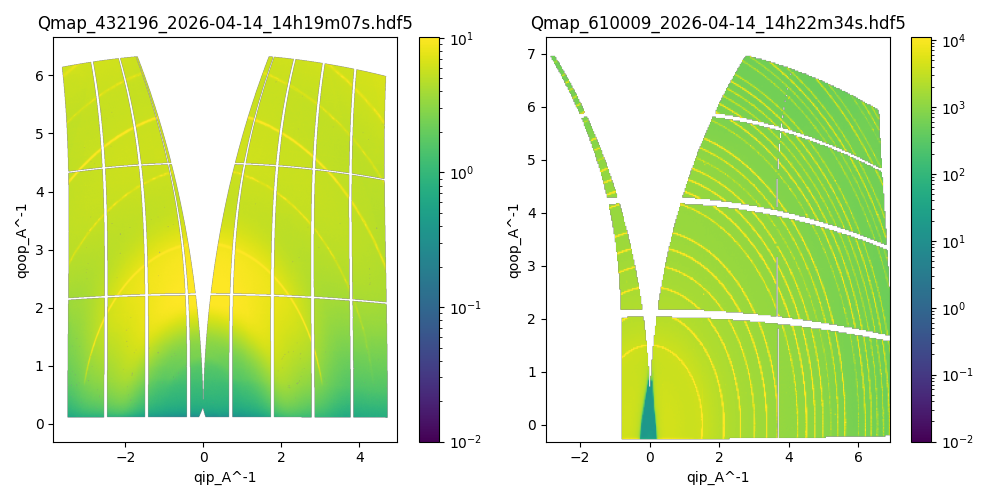

In [4]:
example_qmapfiles=['Qmap_432196_2026-04-14_14h19m07s.hdf5',
                  'Qmap_610009_2026-04-14_14h22m34s.hdf5']
combo_plotter.plot_files(example_qmapfiles,logscale=True)

here a new interactive combined plot is given showing the two Qmaps side-by-side 

![image2.png](../images/combo_qmap.png)

# Comparing datasets which have stacked data along 1 or more dimensions

If you dataset is a stack of data, either a stack of images or a stack of line profiles, you can select a specific slice for comparison



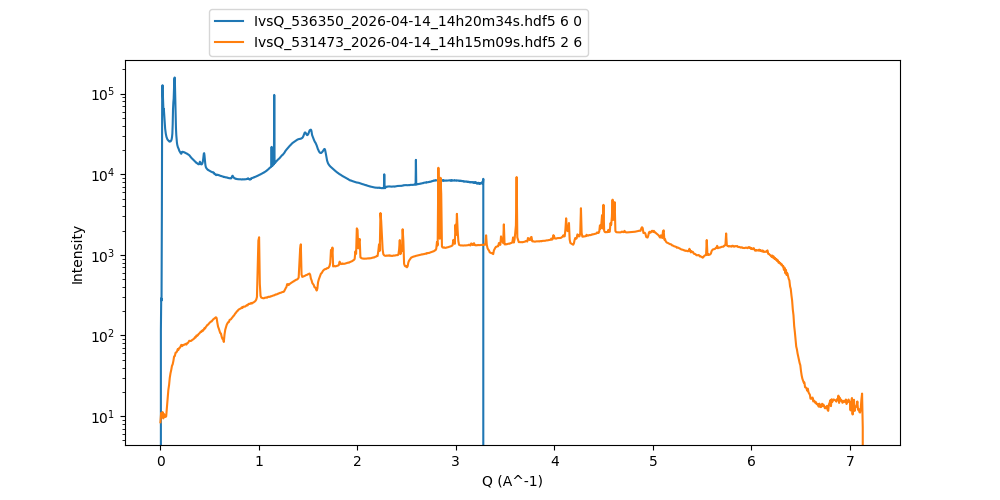

In [13]:
filenames=['IvsQ_536350_2026-04-14_14h20m34s.hdf5' ,'IvsQ_531473_2026-04-14_14h15m09s.hdf5']

# set the values for the corresponding indices
ind1vals=np.array([6,2])
ind2vals=np.array([0,6])

# call the plotter with index values and logscale option
combo_plotter.plot_files(filenames,ind1vals,ind2vals,logscale=True)

This will output a comparison plot showing the slices selected for both files

![image3.png](../images/combo_slice_multi.png)

To compare multiple slices from the same file you can create a list of the same file repeated and then specify the indices for each slice you want to compare. Here we are comparing 5 different slices from the same file, with varying ind1 values and constant ind2 values.


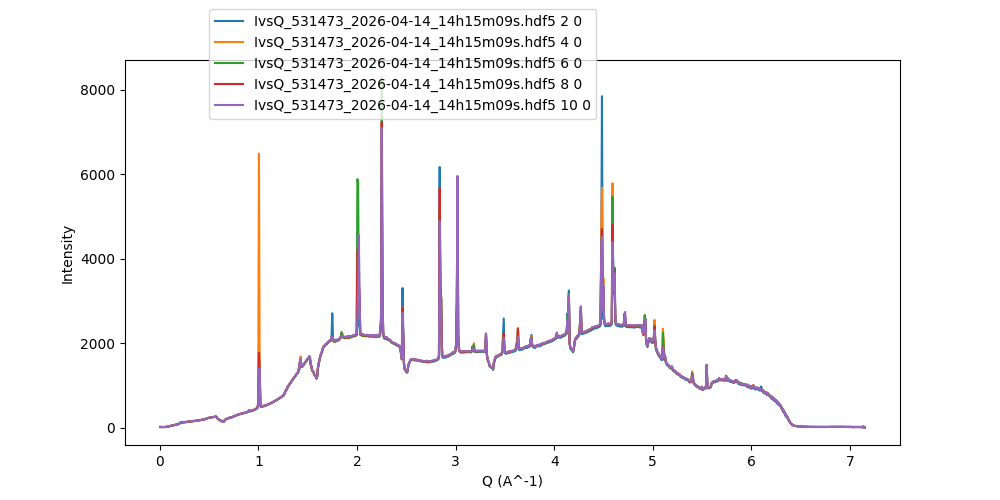

In [ ]:
repeated_file=['IvsQ_531473_2026-04-14_14h15m09s.hdf5']*5
ind1vals=np.array([2,4,6,8,10])
ind2vals=np.array([0,0,0,0,0,0,0])
combo_plotter.plot_files(repeated_file,ind1vals,ind2vals,logscale=False)

This will output a plot comparing the multiple slices from the same file e.g. 

![image4.png](../images/combo_slice_individual.png)